In [ ]:
import os
import talib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler, KBinsDiscretizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import data_loader as data_loader # merge data loader file and preprocess file 
from cnn_lstm import rolling_zscore_matrix
from cnn_lstm import LstmFeatureProcessor, LstmTargetProcessor, LstmFactorAnalyzer #proproceesing data for lstm
from cnn_lstm import LSTMPredictor, RMSELoss, create_sequences #lstm structure
from modeling import win_rate, plot_true_pred, plot_loss, regression_metrics
from backtesting import get_tanh_signal, plot_trade_signals
from backtesting import backtest_strategy, plot_backtest_strategy

# from google.colab import drive
# drive.mount('/content/drive')
#run in the google colab use gpu A100 for faster training


# 1. Preprocessing 

In [ ]:
TEST_DAYS = 14
ROLLING_WINDOW = 60
TARGET_SCALE = 100
FEATURES_CONT = None # for continuous features if any
FEATURES_CAT = None # for categorical features if any

btc_path = '/bitcoin/data/btcusd_1-min_data.csv',
eth_path = '/bitcoin/data/ETH_USD_1min_2020_2025.csv',
eur_path = '/bitcoin/data/EUR_USD_1min_2020_2025.csv',
gld_path = '/bitcoin/data/GLD_1min_2020_2025.csv',
spy_path = '/bitcoin/data/SPY_1min_2020_2025.csv',
vixy_path = '/bitcoin/data/VIXY_1min_2020_2025.csv'

In [3]:
raw_df = data_loader.build_merged_dataset()

# 1. Preprocessing
df = data_loader.preprocess_merged_df(raw_df)

# 2. Feature engineering (pure past)
lstmfp = LstmFeatureProcessor(rolling_smooth=60) # Increased rolling_smooth
df_feat = lstmfp.process_all(df)
feature_cols = lstmfp.get_feature_columns(df_feat)

# 3. Target generation (future)
lstmtp = LstmTargetProcessor(price_col='Close', window=30)
btc, _ = lstmtp.fit_transform(df_feat)  # norm_cols 不用
target_cols = ['target_log_return','target_cum_return_30m','target_binary']

# 4. Drop rows with NaN
btc = btc.dropna(subset=feature_cols + target_cols)

btc.columns.values

Loading CSV files...
Aligning to BTC 7x24 timeline...
Merging all assets...
Adding US market trading hours flag...
Done! Final shape: (368618, 29)


array(['Open', 'High', 'Low', 'Close', 'Volume', 'ETH/USD_open',
       'ETH/USD_high', 'ETH/USD_low', 'EUR/USD_open', 'EUR/USD_high',
       'EUR/USD_low', 'GLD_open', 'GLD_high', 'GLD_low', 'GLD_volume',
       'SPY_open', 'SPY_high', 'SPY_low', 'SPY_volume', 'VIXY_open',
       'VIXY_high', 'VIXY_low', 'VIXY_volume', 'US_Trading_Hours',
       'ETH_mask', 'EUR_mask', 'GLD_mask', 'SPY_mask', 'VIXY_mask',
       'ETH/USD_close_ret', 'EUR/USD_close_ret', 'GLD_close_ret',
       'SPY_close_ret', 'VIXY_close_ret', 'Open_lag1', 'Open_lag2',
       'Open_lag3', 'Open_lag5', 'Open_lag10', 'Open_lag15', 'Open_lag30',
       'High_lag1', 'High_lag2', 'High_lag3', 'High_lag5', 'High_lag10',
       'High_lag15', 'High_lag30', 'Low_lag1', 'Low_lag2', 'Low_lag3',
       'Low_lag5', 'Low_lag10', 'Low_lag15', 'Low_lag30', 'Close_lag1',
       'Close_lag2', 'Close_lag3', 'Close_lag5', 'Close_lag10',
       'Close_lag15', 'Close_lag30', 'Volume_lag1', 'Volume_lag2',
       'Volume_lag3', 'Volume_lag5

# 2. Feature Engineering

Factor Analyzer Initialized. Samples: 346392
   -> Calculating IC & ICIR...


/Users/yishanranxin./anaconda3/envs/6.86x/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/yishanranxin./Desktop/bitcoin/cnn_lstm.py:433: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  g_ic, _ = spearmanr(self.clean_df[feature], self.clean_df[self.target])
/Users/yishanranxin./Desktop/bitcoin/cnn_lstm.py:433: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  g_ic, _ = spearmanr(self.clean_df[feature], self.clean_df[self.target])
/Users/yishanranxin./Desktop/bitcoin/cnn_lstm.py:433: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  g_ic, _ = spearmanr(self.clean_df[feature], self.clean_df[self.target])
/Users/yishanranxin./Desktop/bitcoin/cnn_lstm.py:433: ConstantInputWarning: An input array is constant; the correlation 

   -> Calculating Mutual Information (Non-linear dependency)...
   -> Features passing signal threshold: 72 / 133
   -> Removing redundant features (Threshold > 0.2)...
      Dropped 65 redundant features.
Final Selected Features: 7


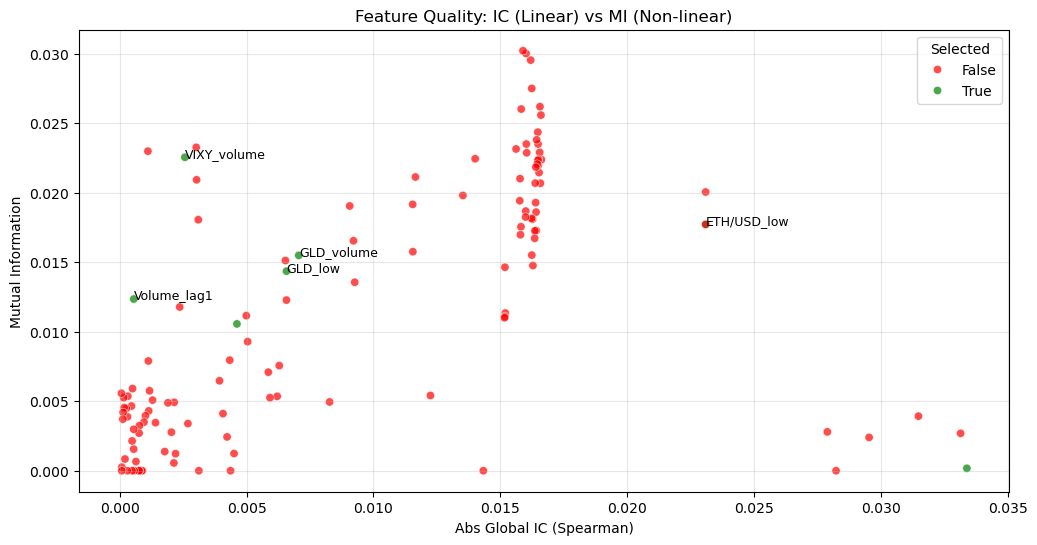

Selected Features List:
['VIXY_volume', 'RSI21', 'ETH/USD_low', 'Volume_lag1', 'ETH/USD_close_ret_lag15', 'GLD_low', 'GLD_volume']


In [4]:
test_len = TEST_DAYS * 1440 # 14 days of minute data
split_index = len(btc) - test_len

train_df = btc.iloc[:split_index] 
test_df = btc.iloc[split_index:]

# Factor Analysis to select features in training set, in order to avoid lookahead bias
lstmanalyzer = LstmFactorAnalyzer(df=train_df, feature_cols=feature_cols, target_col='target_cum_return_30m_norm')
selected_features, metrics_df = lstmanalyzer.run_full_analysis(
    ic_threshold=0.015,   # ic_threshold: the minimum absolute IC required
    mi_threshold=0.01,    # mi_threshold: the minimum mutual information required
    corr_threshold=0.2,   # corr_threshold: the maximum allowed correlation between selected features
    top_n=60            
)

lstmanalyzer.plot_analysis(metrics_df, selected_features)
print("Selected Features List:")
print(selected_features)


In [ ]:
# Choosed by factor analyzer
selected_features = ['RSI21', 'GLD_volume', 'ETH/USD_close_ret_lag15', 'GLD_low', 'Volume_lag1', 'VIXY_volume', 'ETH/USD_low']

In [5]:
FEATURES_CONT = selected_features
FEATURES_CAT = ['US_Trading_Hours']
ROLLING_WINDOW = 60

print(f"Applying Rolling Z-Score (window={ROLLING_WINDOW})...")

# Rolling Z-score for continuous features 
X_cont_scaled = rolling_zscore_matrix(btc, FEATURES_CONT, window=ROLLING_WINDOW)
X_cat = btc[FEATURES_CAT].loc[X_cont_scaled.index].copy()
X = pd.concat([X_cont_scaled, X_cat], axis=1)
X = X.replace([np.inf, -np.inf], 0).fillna(0)

# Target
y = btc['target_cum_return_30m_norm'].copy()
y = y.loc[X.index]
y = y * TARGET_SCALE

print("-" * 30)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features used: {X.columns.values} ({len(X.columns)})")
print(f"Target example (first 5): \n{y.head().values}")
print(f"Feature statistics (mean should be ~0): \n{X[FEATURES_CONT[0]].head()}")
print("-" * 30)

Applying Rolling Z-Score (window=60)...
------------------------------
X shape: (366493, 8)
y shape: (366493,)
Features used: ['VIXY_volume' 'RSI21' 'ETH/USD_low' 'Volume_lag1'
 'ETH/USD_close_ret_lag15' 'GLD_low' 'GLD_volume' 'US_Trading_Hours'] (8)
Target example (first 5): 
[-31.86078492 -26.44084019 -25.88674165 -44.77910782 -22.05926478]
Feature statistics (mean should be ~0): 
Timestamp
2025-01-02 06:01:00-05:00    1.054922
2025-01-02 06:02:00-05:00   -0.510388
2025-01-02 06:03:00-05:00   -0.492166
2025-01-02 06:04:00-05:00    1.830766
2025-01-02 06:05:00-05:00    1.765331
Name: VIXY_volume, dtype: float64
------------------------------


# 3. Modeling - LSTM

## 3.1 Initialization
### LSTM Predictor Architecture
- **Input:** Sequence of features (input_dim)  

#### 1. CNN Layer
- 1D convolution: `in_channels = input_dim`, `out_channels = 32`, `kernel_size = 3`, `padding = 1`
- Activation: ReLU
- BatchNorm1d(32)  

#### 2. Fully Connected (Feature FC)
- Linear: `32 → hidden_dim`
- Activation: ReLU
- Dropout (dropout rate = 0.2)  

#### 3. LSTM
- Input size: `hidden_dim`
- Hidden size: `hidden_dim`
- Number of layers: 2
- Batch first: True
- Dropout: 0.2  

#### 4. Layer Normalization
- LayerNorm(hidden_dim)  

#### 5. Attention Layer
- Linear(hidden_dim → hidden_dim//2)
- Tanh activation
- Linear(hidden_dim//2 → 1)  

#### 6. Output Fully Connected
- Linear(hidden_dim → 64) → ReLU → Dropout
- Linear(64 → 32) → ReLU → Dropout
- Linear(32 → 1) → Output  

#### 7. Weight Initialization
- Xavier / Orthogonal initialization  

#### 8. Loss Function
- RMSE (Root Mean Squared Error)  


In [6]:
# LSTM Model Parameters
FINAL_MODEL = None
SCALER = None
Y_SCALER = None
FEATURE_COLUMNS = selected_features
TARGET_COLUMN = "target_cum_return_30m_norm"

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

SEQUENCE_LENGTH = 60 # 60 minutes

Using device: cpu


In [7]:
TEST_DAYS = 14
test_len = TEST_DAYS * 1440
split_index = len(X) - test_len

X_train_scaled = X.iloc[:split_index].values
y_train_scaled = y.iloc[:split_index].values

X_val_scaled = X.iloc[split_index:].values
y_val_scaled = y.iloc[split_index:].values

print(f"{'-'*50}")
print("Train X:", X_train_scaled.shape, "Train y:", y_train_scaled.shape)
print("Test X:", X_val_scaled.shape, "Test y:", y_val_scaled.shape)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQUENCE_LENGTH)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, SEQUENCE_LENGTH)

print(f"{'-'*50}")
print("Train sequence shape:", X_train_seq.shape, y_train_seq.shape)
print("Val sequence shape:", X_val_seq.shape, y_val_seq.shape)
print(f"Time step = {SEQUENCE_LENGTH}; Features = {X_train_seq.shape[2]}")
print(f"{'-'*50}")


--------------------------------------------------
Train X: (346333, 8) Train y: (346333,)
Test X: (20160, 8) Test y: (20160,)
--------------------------------------------------
Train sequence shape: (346273, 60, 8) (346273, 1)
Val sequence shape: (20100, 60, 8) (20100, 1)
Time step = 60; Features = 8
--------------------------------------------------


In [8]:
# Convert to PyTorch Tensor
train_ds = TensorDataset(torch.FloatTensor(X_train_seq).to(DEVICE),
                         torch.FloatTensor(y_train_seq).reshape(-1, 1).to(DEVICE))

val_ds = TensorDataset(torch.FloatTensor(X_val_seq).to(DEVICE),
                        torch.FloatTensor(y_val_seq).reshape(-1, 1).to(DEVICE))

train_loader = DataLoader(train_ds, batch_size = 128, shuffle=True) #64
val_loader = DataLoader(val_ds, batch_size = 128, shuffle=False) #64

In [9]:
#Parameters has been tuned by random search and manual tuning
FINAL_MODEL = LSTMPredictor(input_dim=len(X.columns)).to(DEVICE)
criterion = RMSELoss() 
optimizer = optim.Adam(FINAL_MODEL.parameters(), lr = 0.0002, weight_decay = 2e-3) #lr 0.0005, 0.0001, 0.00015
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 3) #factor 0.3

In [121]:
# Training
print("Starting training...")
best_loss = float('inf')
patience = 8 # early stopping
counter = 0
train_losses = []
val_losses = []

for epoch in range(100):
    FINAL_MODEL.train()
    total_loss = 0

    for batch_X, batch_y in train_loader: # each batch X is like [128, 60, 60] 128 batch, 60 time_step, 60 features
        optimizer.zero_grad()
        preds = FINAL_MODEL(batch_X)     # forward
        loss = criterion(preds, batch_y) # loss
        loss.backward()                  # BP
        torch.nn.utils.clip_grad_norm_(FINAL_MODEL.parameters(), 1.0) # Gradient Clipping
        optimizer.step()                 # update theta
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    #Validation
    val_loss_total = 0
    FINAL_MODEL.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            val_loss_total += criterion(FINAL_MODEL(xb), yb).item()
    val_loss = val_loss_total / len(val_loader)
    val_losses.append(val_loss)


    scheduler.step(val_loss) # adjust learning rate

    print(f"Epoch {epoch+1}: Train Loss {avg_loss:.5f}, Val Loss {val_loss:.5f}, LR: {scheduler.get_last_lr()[0]:.6f}")

    #Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(FINAL_MODEL.state_dict(), 'best_model.pth') # save the best
    else:
        counter += 1
        if counter >= patience:
            print('Early stopping !!!')
            break


Starting training...
Epoch 1: Train Loss 83.70248, Val Loss 84.20889, LR: 0.000200
Epoch 2: Train Loss 83.45132, Val Loss 84.26314, LR: 0.000200
Epoch 3: Train Loss 83.40384, Val Loss 83.92761, LR: 0.000200
Epoch 4: Train Loss 83.32606, Val Loss 84.21788, LR: 0.000200
Epoch 5: Train Loss 83.27515, Val Loss 84.10724, LR: 0.000200
Epoch 6: Train Loss 83.21918, Val Loss 83.90414, LR: 0.000200
Epoch 7: Train Loss 83.18027, Val Loss 84.14746, LR: 0.000200
Epoch 8: Train Loss 83.14901, Val Loss 83.95847, LR: 0.000200
Epoch 9: Train Loss 83.15843, Val Loss 83.77595, LR: 0.000200
Epoch 10: Train Loss 83.18101, Val Loss 83.97975, LR: 0.000200
Epoch 11: Train Loss 83.20014, Val Loss 84.11957, LR: 0.000200
Epoch 12: Train Loss 83.20553, Val Loss 83.92525, LR: 0.000200
Epoch 13: Train Loss 83.23703, Val Loss 84.07500, LR: 0.000100
Epoch 14: Train Loss 83.14388, Val Loss 84.01941, LR: 0.000100
Epoch 15: Train Loss 83.15182, Val Loss 84.11093, LR: 0.000100
Epoch 16: Train Loss 83.16028, Val Loss 84.

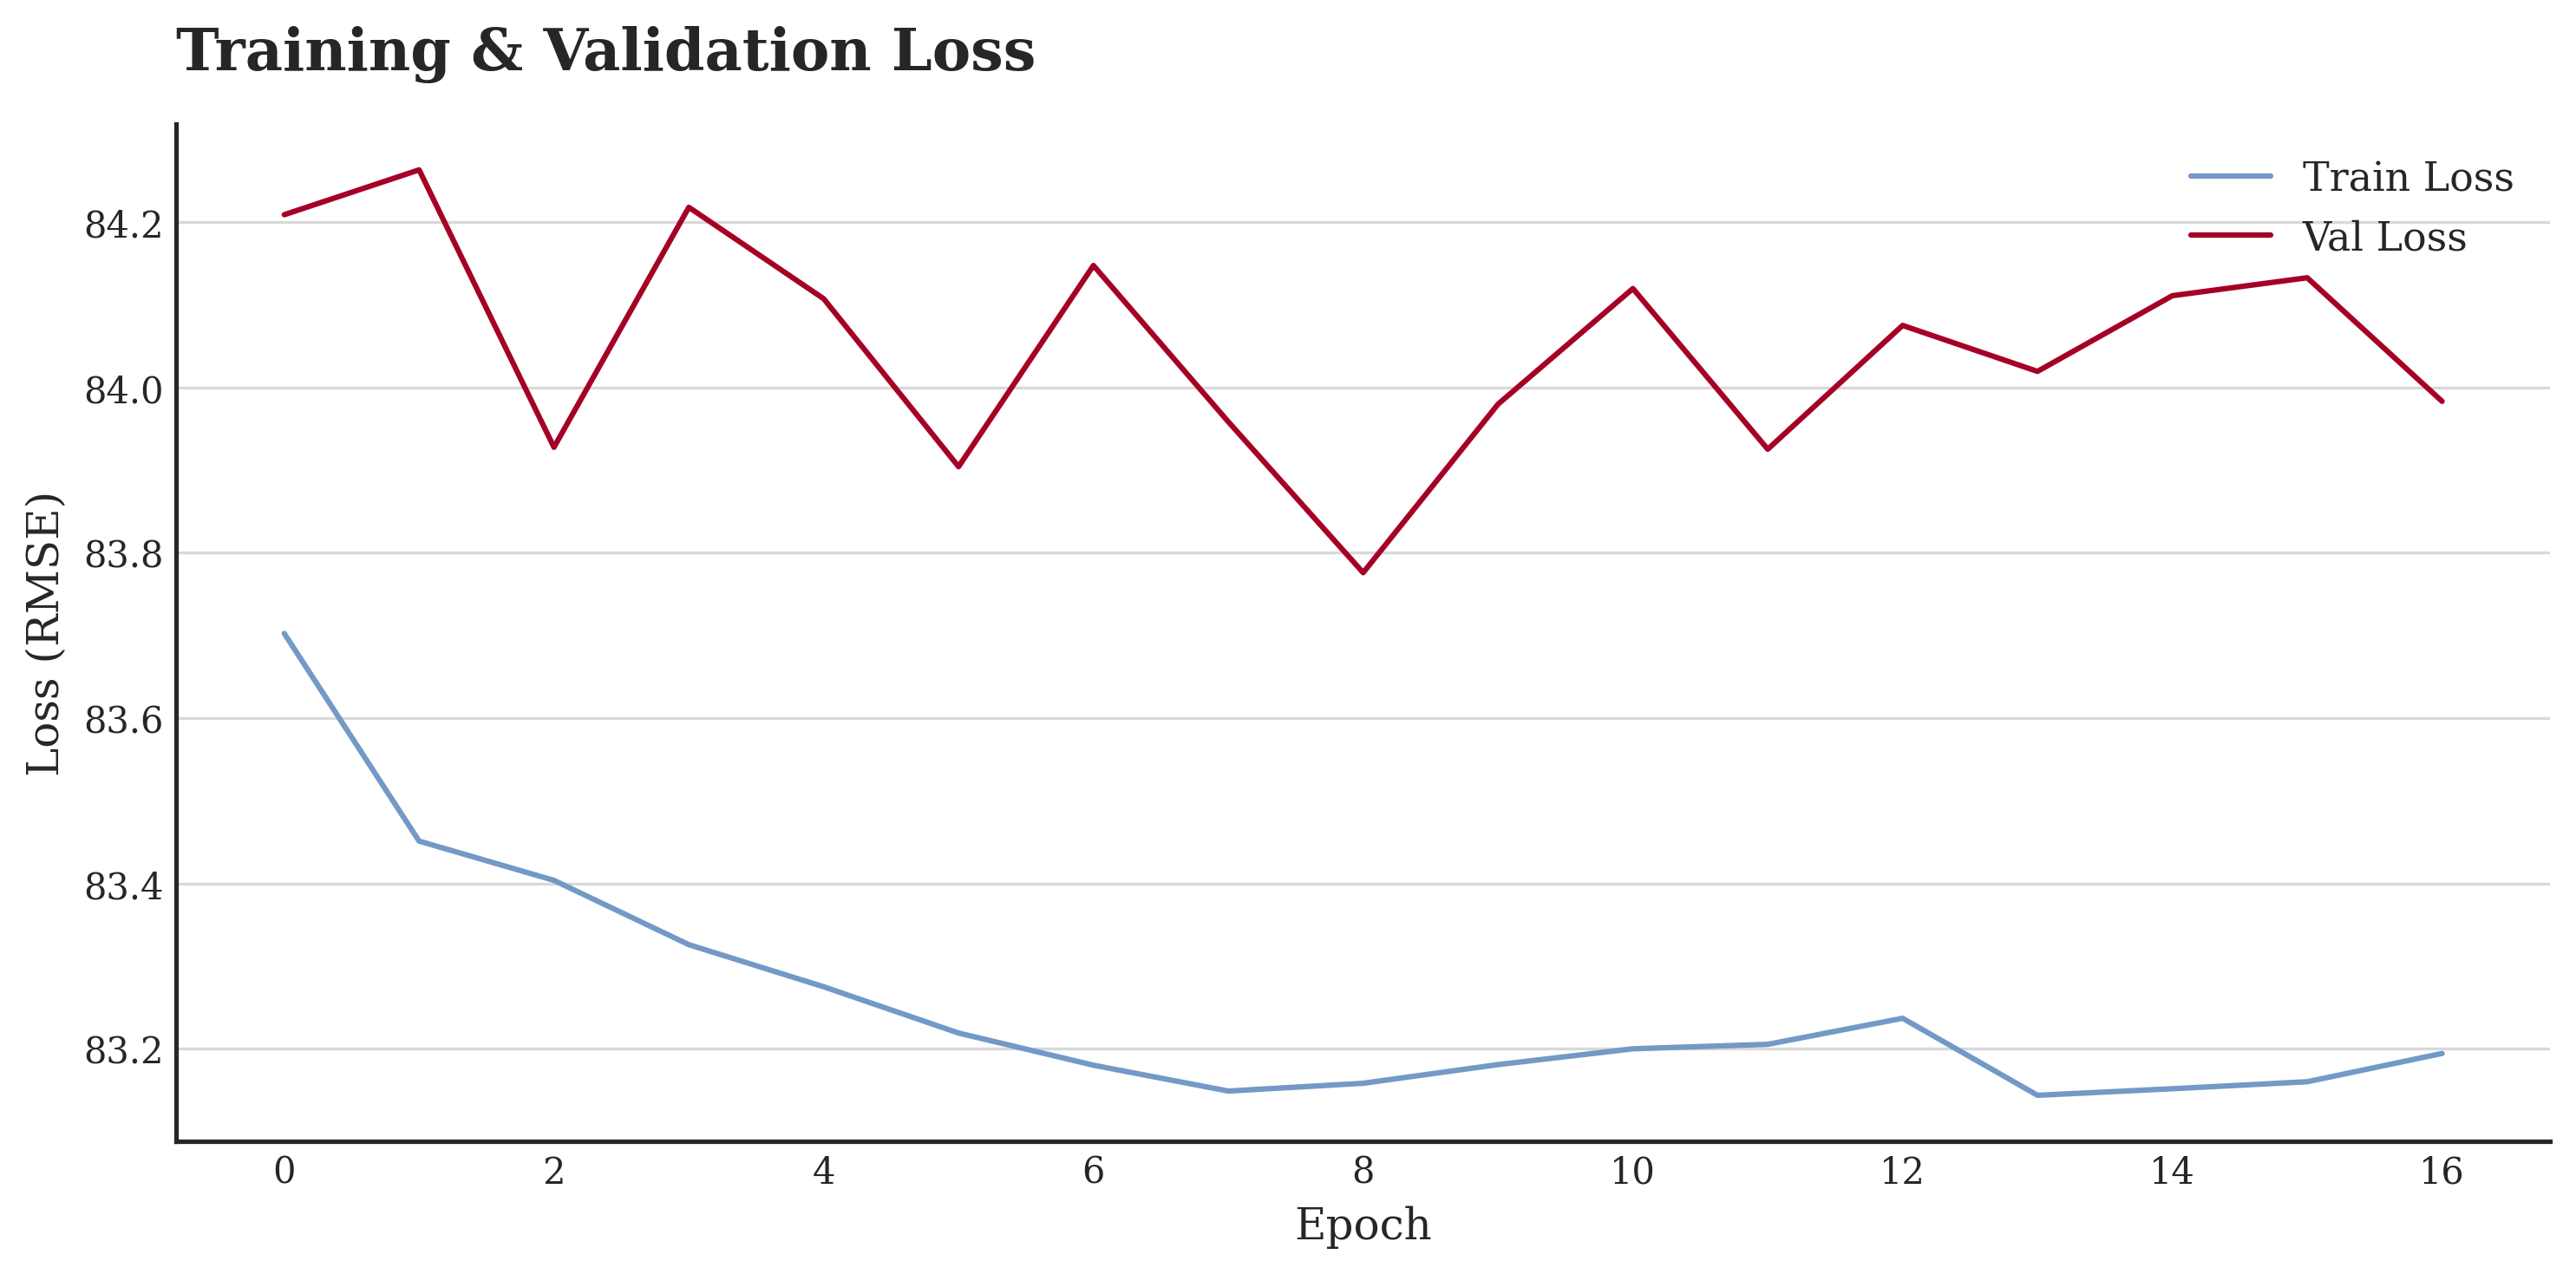

In [154]:
plot_loss(train_losses, val_losses)

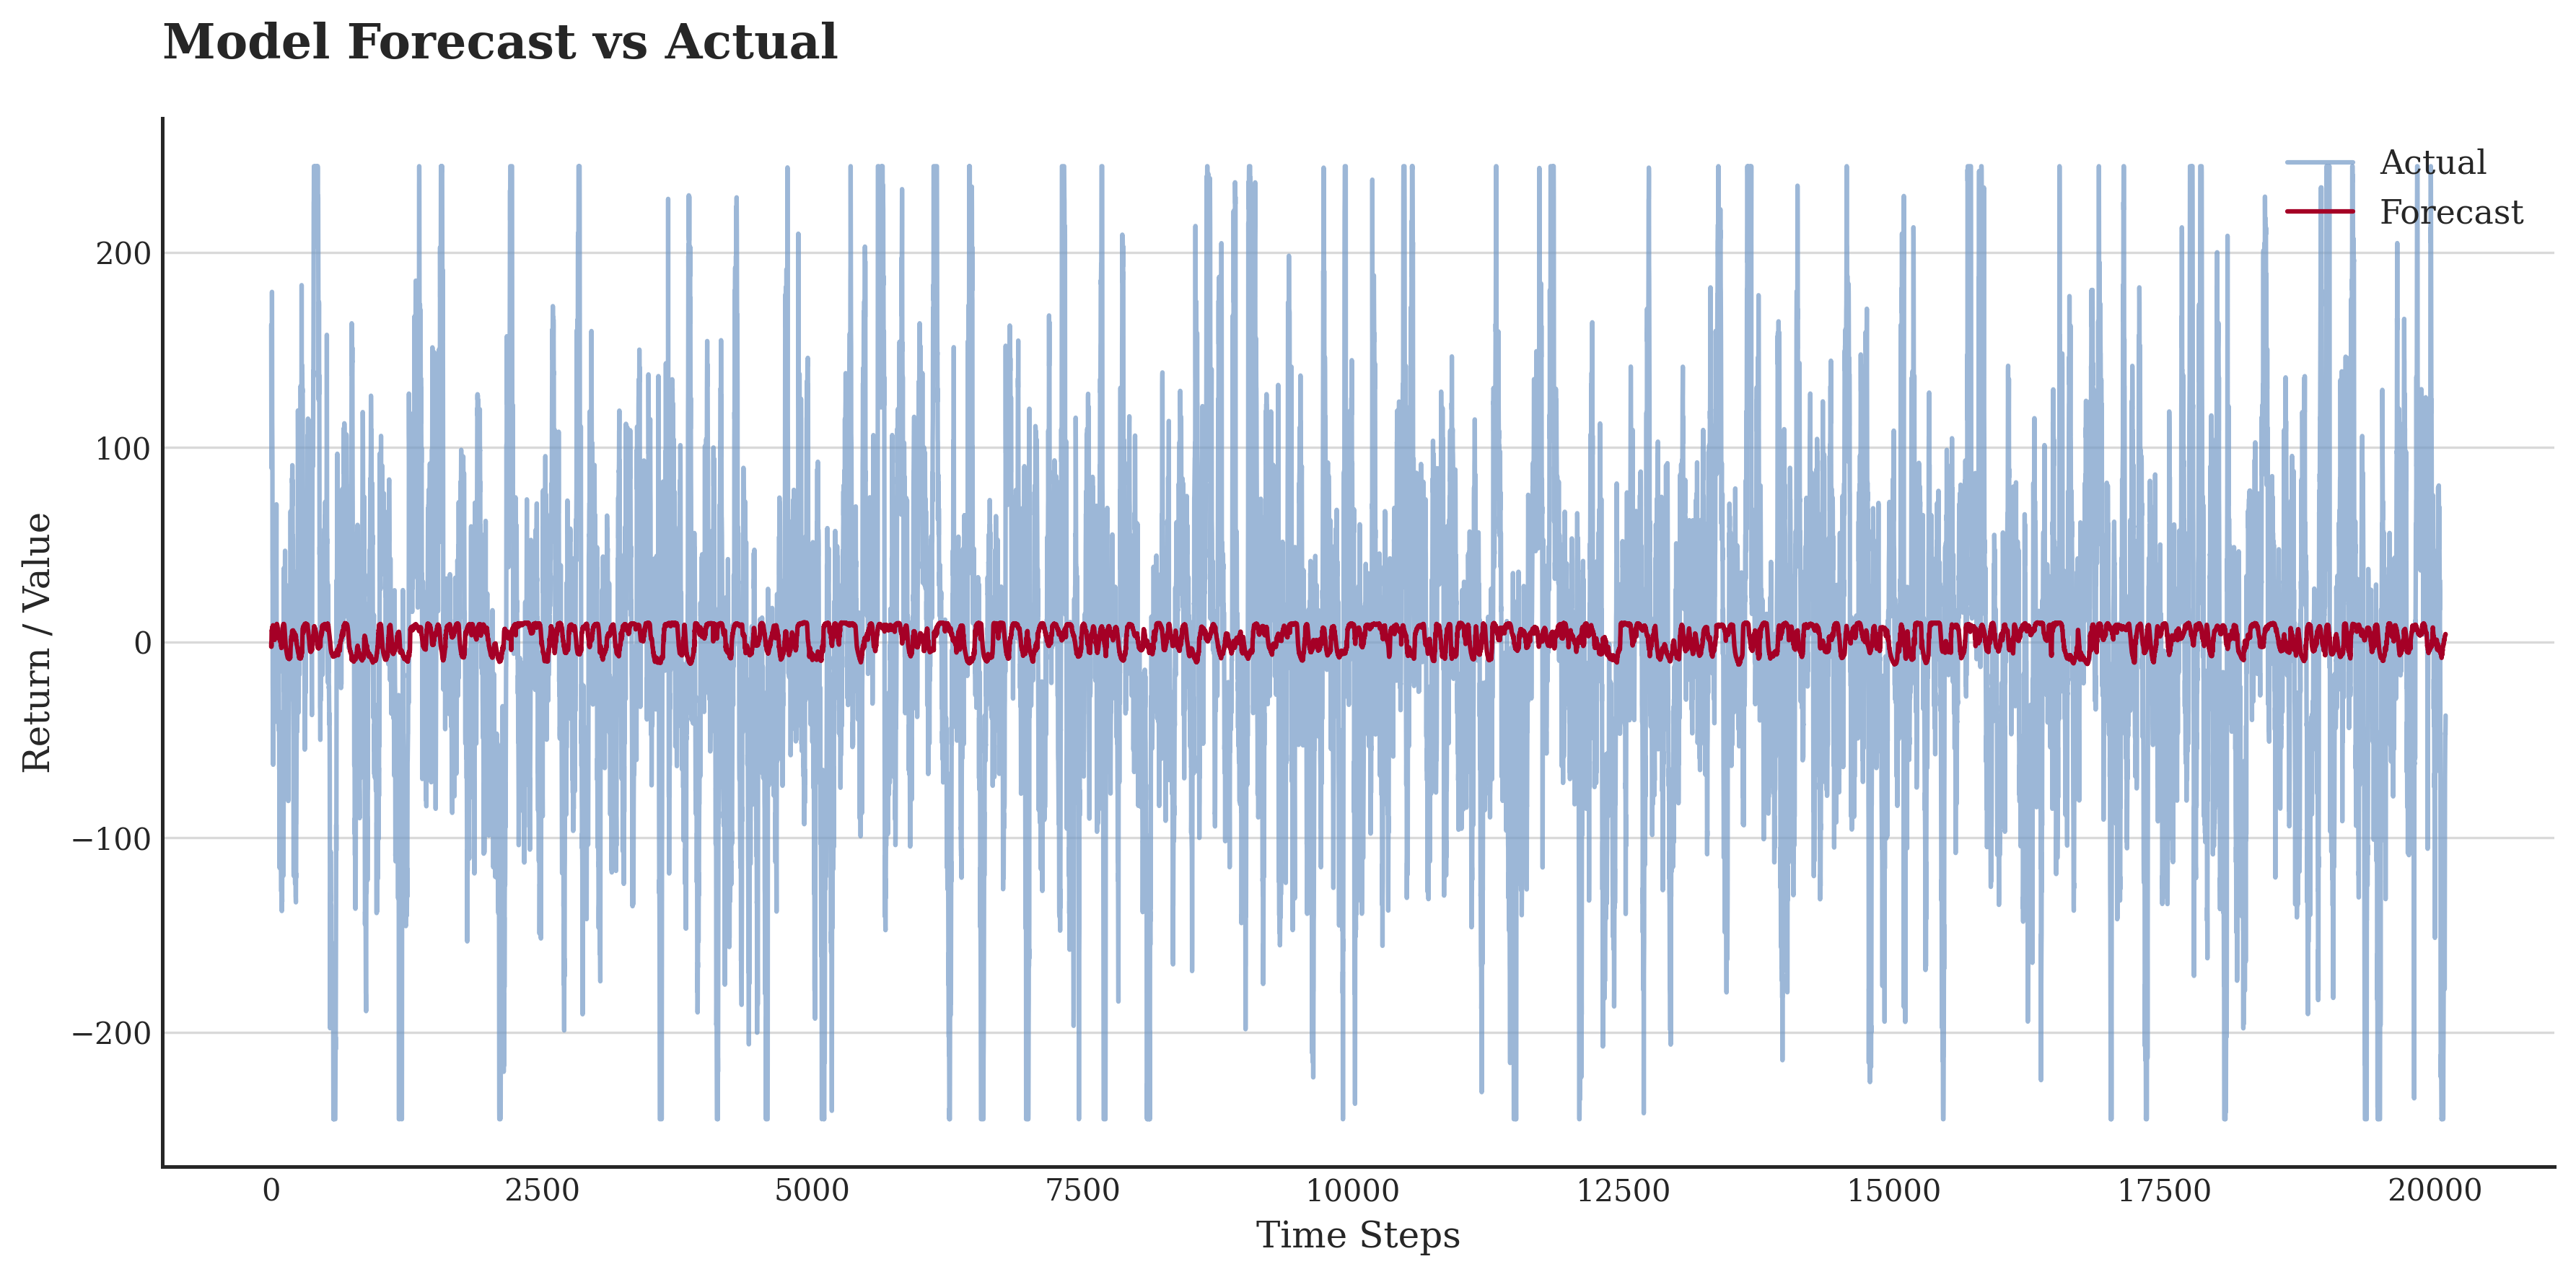

----------------------------------------
📊 Model Performance Metrics
----------------------------------------
MSE          : 7676.150391
MAE          : 66.121651
RMSE         : 87.613643
R² Score     : 0.0053
Win Rate     : 52.91%
----------------------------------------


np.float64(0.5290547263681592)

In [ ]:
# Save and Load the Best Model#
save_path = '/bitcoin/lstm_best_model.pth'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(FINAL_MODEL.state_dict(), save_path)

FINAL_MODEL = LSTMPredictor(input_dim=len(X.columns)).to(DEVICE)
FINAL_MODEL.load_state_dict(torch.load(save_path))

FINAL_MODEL.eval()
preds_list = []
true_list = []
with torch.no_grad():
    for xb, yb in val_loader:    
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        pred = FINAL_MODEL(xb).view(-1)
        preds_list.append(pred.cpu())
        true_list.append(yb.view(-1).cpu())

y_pred = torch.cat(preds_list).numpy()
y_true = torch.cat(true_list).numpy()

plot_true_pred(y_true, y_pred)
regression_metrics(y_true, y_pred)
win_rate(y_true, y_pred)

In [ ]:
# inverse transform to get real scale values from lstm target processor
scaler_center = lstmtp.scaler.center_[1]
scaler_scale = lstmtp.scaler.scale_[1]
val_vol = lstmtp.volatility.values[-len(y_pred):]

#Inverse Transform
# 1. Inverse target scale (y_scaled = y_real / 100)
y_pred_1 = y_pred * TARGET_SCALE #100
y_true_1 = y_true * TARGET_SCALE

# 2. Inverse RobustScaler (X_real = X_scaled * scale + center)
y_pred_2 = y_pred_1 * scaler_scale + scaler_center
y_true_2 = y_true_1 * scaler_scale + scaler_center

# 3. Return = Norm_Return * Volatility
real_y_pred = y_pred_2 * val_vol
real_y_true = y_true_2 * val_vol

print(f"Range of True Return): Min {real_y_true.min():.5f}, Max {real_y_true.max():.5f}")
print(f"Range of Pred Return : Min {real_y_pred.min():.5f}, Max {real_y_pred.max():.5f}")


真实收益率范围 (True): Min -290.60990, Max 257.90795
预测收益率范围 (Pred): Min -11.19890, Max 8.45693


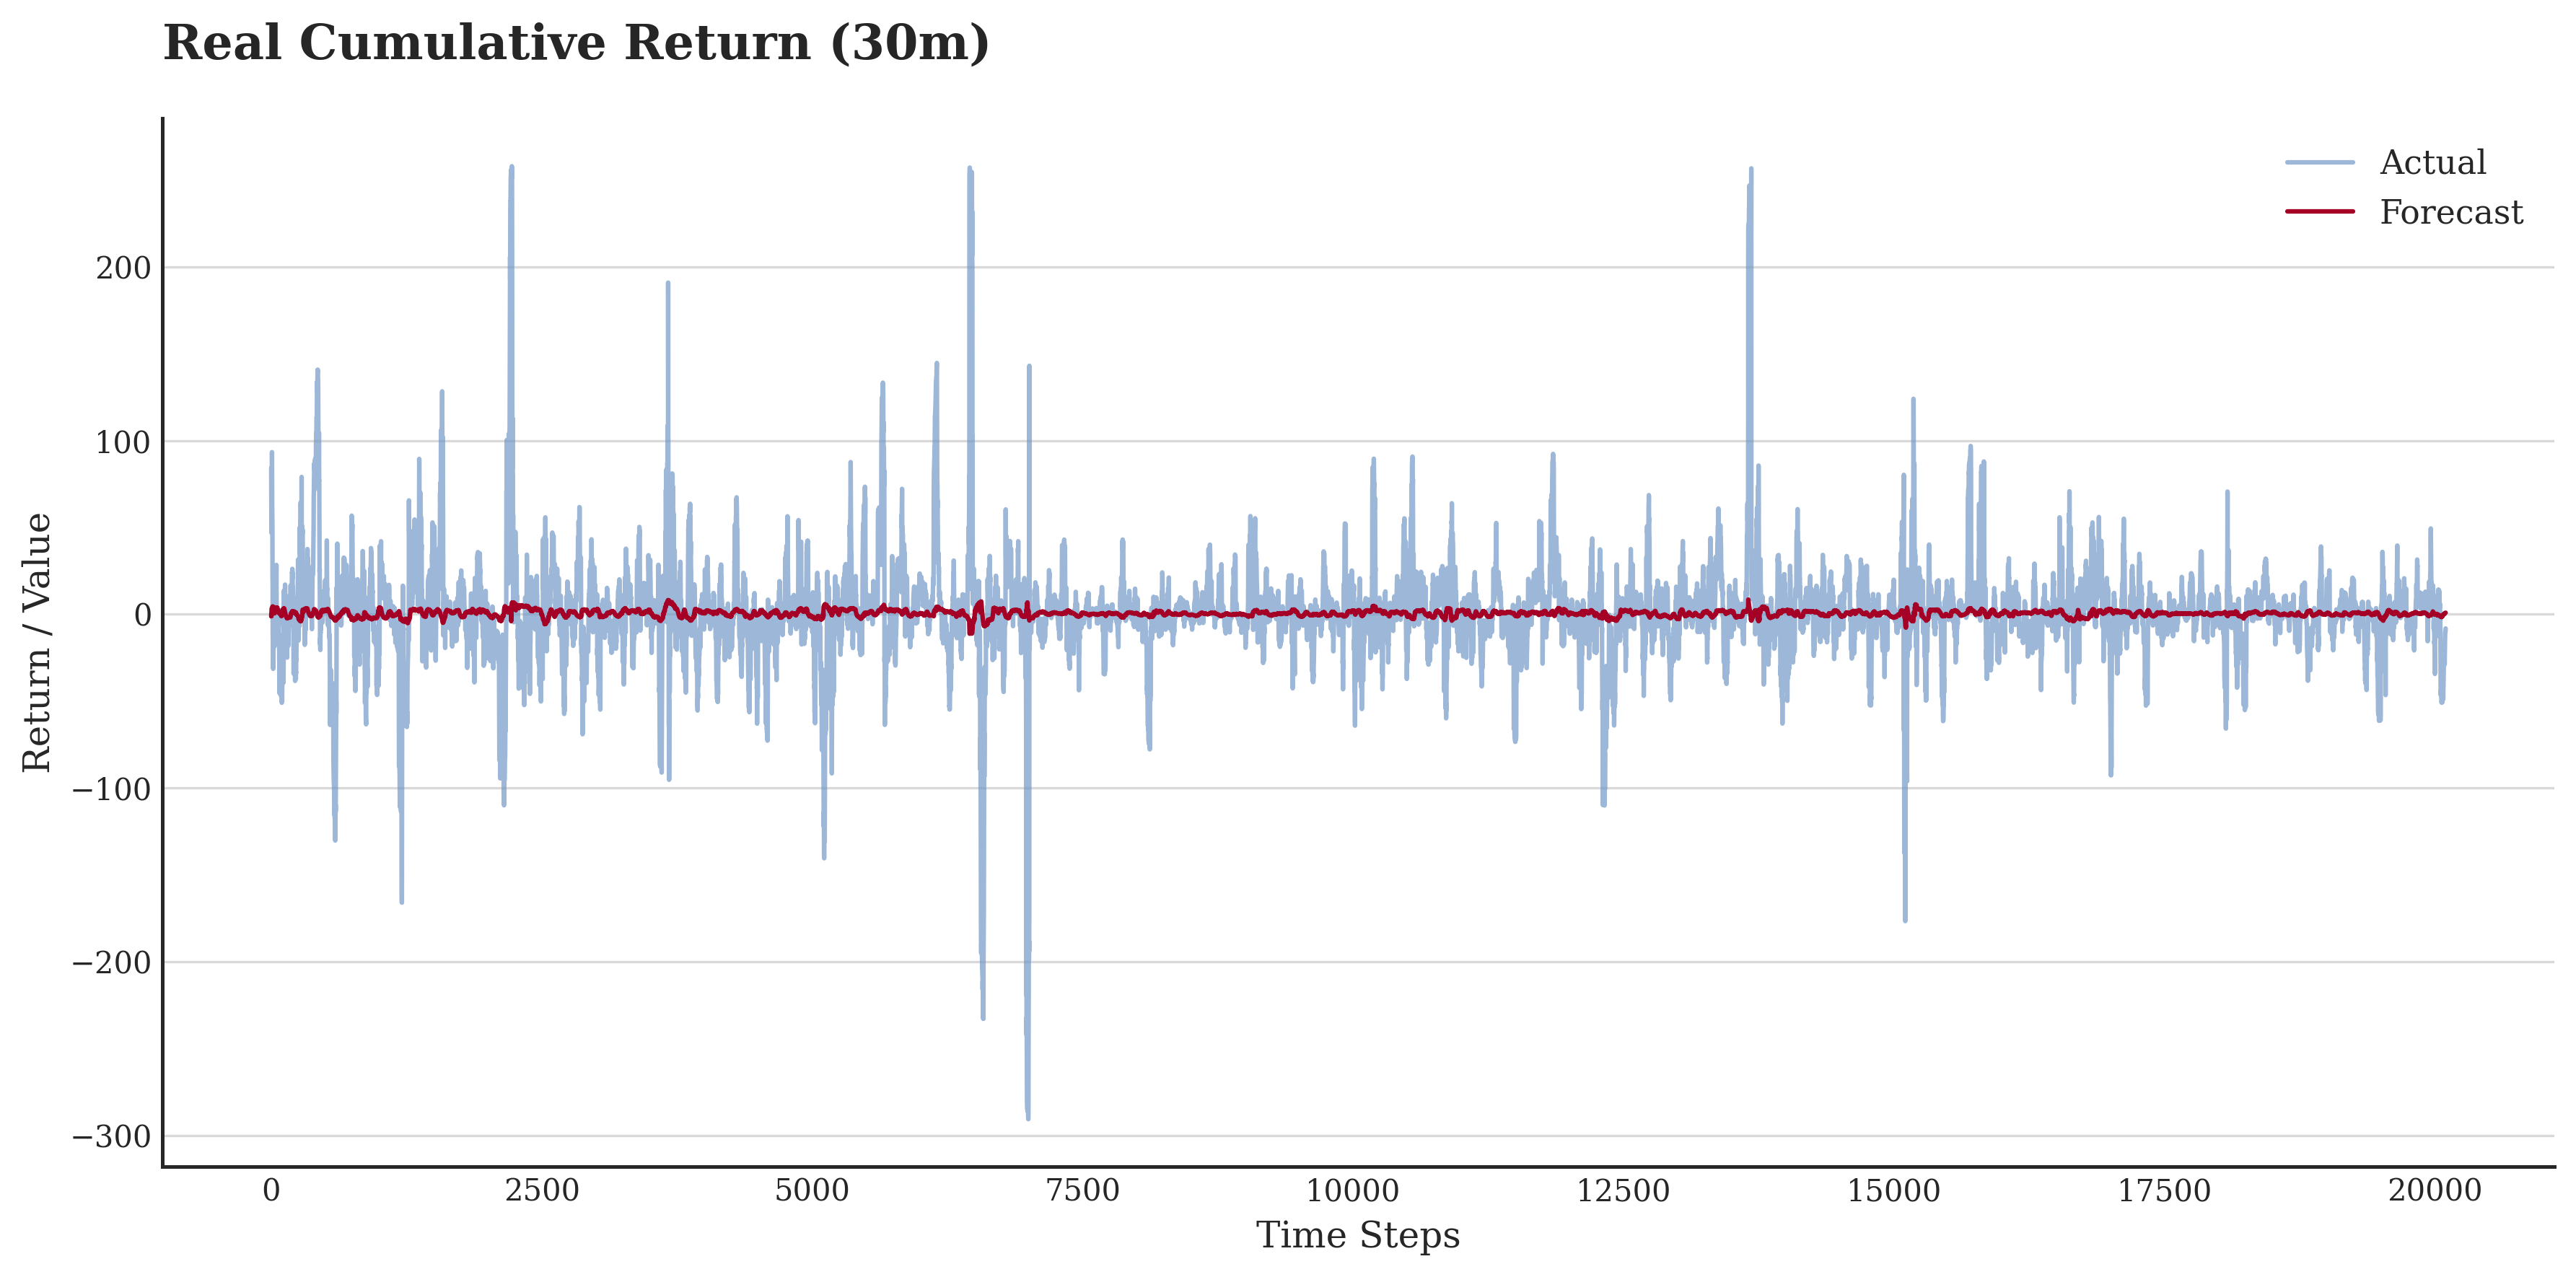

----------------------------------------
📊 Model Performance Metrics
----------------------------------------
MSE          : 895.044073
MAE          : 16.736994
RMSE         : 29.917287
R² Score     : 0.0046
Win Rate     : 52.91%
----------------------------------------
Real Scale Win Rate: 52.91%


In [ ]:
""" Real scale results visualization and metrics """
# plotting real scale results
plot_true_pred(real_y_true, real_y_pred, title="Real Cumulative Return (30m)")
# Calculate metrics on real scale values
metrics = regression_metrics(real_y_true, real_y_pred)

# 4. Backtesting

⚡ 自动计算 Scale Factor: 0.58 (基于数据标准差)
------------------------------
Signal Range: [-1.0000, 0.9999]
Signal Mean:  0.1927
Signal Std:   0.5863
------------------------------


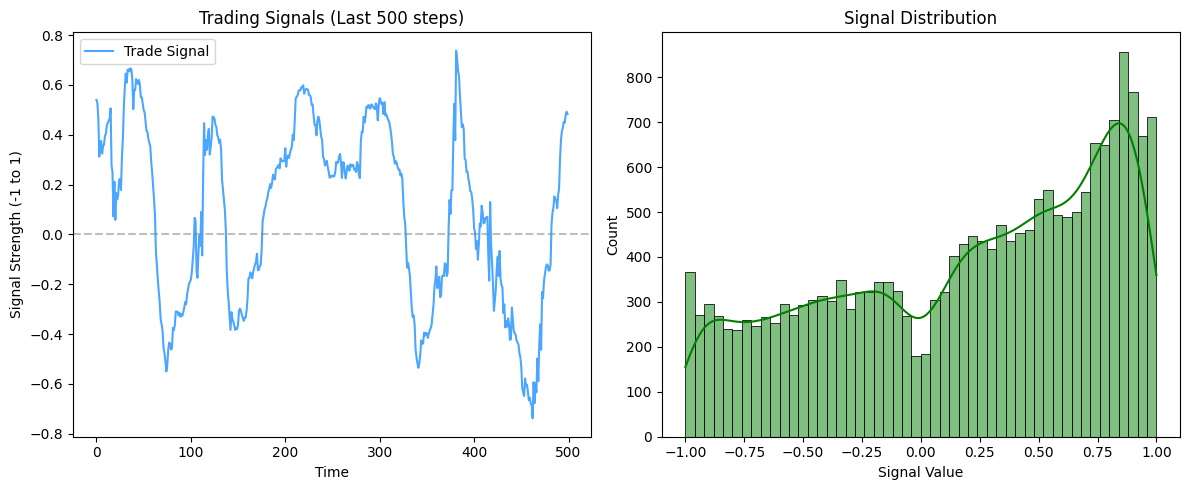

In [ ]:
# getting trade signals and plotting
signals = get_tanh_signal(real_y_pred)
plot_trade_signals(signals)

In [ ]:
# Get real step returns for backtesting

num_test_samples = len(signals)
real_step_returns = btc['target_log_return'].iloc[-num_test_samples:].values
real_step_returns = np.nan_to_num(real_step_returns)

print(f"  - Length of signals: {len(signals)}")
print(f"  - Length of real returns : {len(real_step_returns)}")
print(f"  - Length of test day: {len(signals)/60/24:.2f} days")


  - Length of signals: 20100
  - Length of real returns : 20100
  - Length of test day: 13.96 days



📊 Strategy Performance Comparison (Last 2 Days)
Metric                 | Ideal (No Cost)    | Aggressive (T=0)   | Conservative (T=0.3)
-------------------------------------------------------------------------------------
Total Return (B&H)     | 7.06%              | 7.06%              | 7.06%             
Total Return (Strat)   | 13.30%             | -26.15%            | 3.90%             
Sharpe Ratio           | 15.10              | -36.37             | 4.78              
Sortino Ratio          | 18.11              | -48.52             | 4.57              
Max Drawdown           | -1.58%             | -26.80%            | -3.89%            
Trade Count            | 20100              | 20100              | 9668              
Cost Rate              | 0.00%              | 0.05%              | 0.01%             


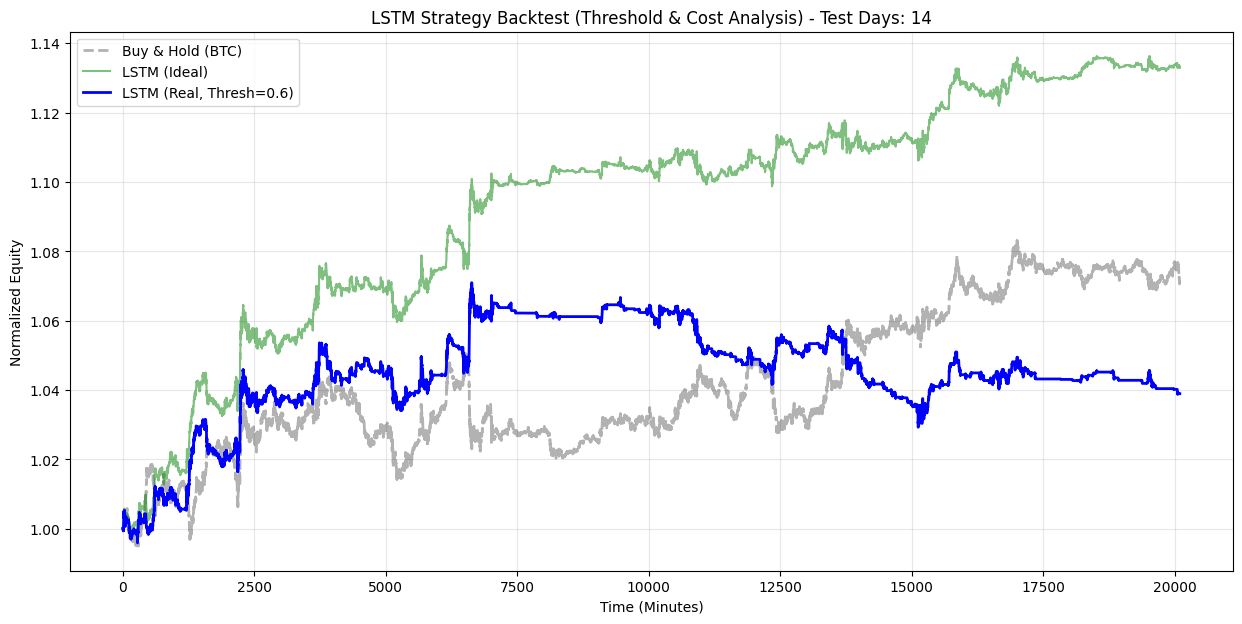

In [ ]:
# ==============================================================================
# Backtesting with Different Thresholds and Costs
# ==============================================================================
plot_backtest_strategy()
# Situation 1: real (Threshold 0.6，0.01% cost)
# only take positions when signal strength > 0.6 (tanh output) to filter noise
res_real = backtest_strategy(signals, real_step_returns, threshold=0.6, cost_rate=0.0001)
# Situation 2: ideal (0 threshold，0 cost) - use to validate model prediction ability
res_ideal = backtest_strategy(signals, real_step_returns, threshold=0.0, cost_rate=0.0)

# Final results comparison
plot_backtest_strategy(
    signals=signals,
    returns=real_step_returns,
    thresholds=[0.0, 0.6],
    cost_rates=[0.0, 0.0001],
    test_days='Last 14 Days'
)


# Appendix

In [ ]:
save_df = pd.DataFrame({
    "y_true": real_y_true,
    "y_pred": real_y_pred,
    "signals": signals,
    "benchmark": res_ideal["equity_bh"],
    "lstm_cum_return_ideal": res_ideal["equity_strat"],
    "lstm_cum_return_real": res_real["equity_strat"]
})

save_df.to_csv("lstm_outputs.csv", index=False)
print("Saved: model_outputs.csv")

Saved: model_outputs.csv


# Random hyperparameter search for the LSTM model
To perform random hyperparameter search for the LSTM model, I will define a search space for key hyperparameters, then implement a loop that randomly samples these parameters, trains the model, and records its performance.

Here's the plan:
1.  **Define Hyperparameter Search Space**: I will specify the possible values for `learning_rate`, `hidden_dim`, `num_layers`, `dropout`, `batch_size`, and `SEQUENCE_LENGTH`.
2.  **Implement Random Search Loop**: I will create a new code cell that iterates for a set number of trials. In each trial, it will:
    *   Randomly select a combination of hyperparameters.
    *   Re-generate the data sequences and PyTorch DataLoaders if `SEQUENCE_LENGTH` or `batch_size` changes.
    *   Initialize a new `LSTMPredictor` model with the chosen `hidden_dim`, `num_layers`, and `dropout`.
    *   Configure the optimizer with the selected `learning_rate`.
    *   Train the model for a fixed number of epochs or until early stopping (reusing the logic from the previous training cell).
    *   Evaluate the model's performance on the validation set.
    *   Store the hyperparameters and the resulting validation loss (or other metrics) for analysis.
    *   Keep track of the best performing model across all trials.
3.  **Evaluate and Summarize**: After the search, I will analyze the results to identify the best hyperparameter set and discuss the implications for model performance.

Let's proceed with the implementation.
```python
import random
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Define the hyperparameter search space
param_space = {
    'learning_rate': [1e-5, 5e-5, 1e-4, 1.5e-4, 5e-4, 1e-3],
    'hidden_dim': [32, 64, 96, 128],
    'num_layers': [1, 2, 3],
    'dropout': [0.1, 0.2, 0.3, 0.4, 0.5],
    'batch_size': [64, 128, 256, 512],
    'SEQUENCE_LENGTH': [15, 30, 45, 60]
}

num_trials = 20  # Number of random trials to run
results = []
best_overall_val_loss = float('inf')
best_overall_params = None
best_overall_model_state = None

print("Starting Random Hyperparameter Search...")

# Load the full datasets for sequence creation
# X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled are already defined

for i in range(num_trials):
    print(f"\n--- Trial {i+1}/{num_trials} ---")

    # Randomly sample hyperparameters
    lr = random.choice(param_space['learning_rate'])
    hidden_dim = random.choice(param_space['hidden_dim'])
    num_layers = random.choice(param_space['num_layers'])
    dropout = random.choice(param_space['dropout'])
    batch_size = random.choice(param_space['batch_size'])
    seq_len = random.choice(param_space['SEQUENCE_LENGTH'])

    current_params = {
        'learning_rate': lr,
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'dropout': dropout,
        'batch_size': batch_size,
        'SEQUENCE_LENGTH': seq_len
    }
    print(f"Parameters: {current_params}")

    # Re-create sequences and DataLoaders based on the new SEQUENCE_LENGTH and batch_size
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_len)
    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, seq_len)

    train_ds = TensorDataset(torch.FloatTensor(X_train_seq).to(DEVICE),
                             torch.FloatTensor(y_train_seq).reshape(-1, 1).to(DEVICE))
    val_ds = TensorDataset(torch.FloatTensor(X_val_seq).to(DEVICE),
                            torch.FloatTensor(y_val_seq).reshape(-1, 1).to(DEVICE))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Initialize model, criterion, optimizer, scheduler for this trial
    model = LSTMPredictor(
        input_dim=len(X.columns),
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    ).to(DEVICE)
    criterion = RMSELoss() # Use RMSELoss as determined in previous steps
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=3e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    # Training loop for the current trial
    trial_best_val_loss = float('inf')
    trial_counter = 0
    patience = 10 # Early stopping patience for each trial

    for epoch in range(100): # Max epochs for a single trial
        model.train()
        total_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss_total += criterion(model(xb), yb).item()
        val_loss = val_loss_total / len(val_loader)

        scheduler.step(val_loss)

        if val_loss < trial_best_val_loss:
            trial_best_val_loss = val_loss
            trial_counter = 0
        else:
            trial_counter += 1
            if trial_counter >= patience:
                # print(f"  Early stopping in epoch {epoch+1}")
                break
        
        # print(f"  Epoch {epoch+1}: Train Loss {avg_loss:.5f}, Val Loss {val_loss:.5f}, LR: {scheduler.get_last_lr()[0]:.6f}")

    print(f"Trial {i+1} finished. Best Val Loss: {trial_best_val_loss:.5f}")

    # Store results for this trial
    results.append({
        **current_params,
        'val_loss': trial_best_val_loss
    })

    # Check if this trial yielded the overall best model
    if trial_best_val_loss < best_overall_val_loss:
        best_overall_val_loss = trial_best_val_loss
        best_overall_params = current_params
        best_overall_model_state = model.state_dict()
        print(f"  New overall best model found with Val Loss: {best_overall_val_loss:.5f}")

print("\n--- Random Search Complete ---")
results_df = pd.DataFrame(results).sort_values(by='val_loss', ascending=True)
print("\nTop 5 Hyperparameter Combinations:")
print(results_df.head())

print(f"\nBest overall hyperparameters: {best_overall_params}")
print(f"Best overall validation loss: {best_overall_val_loss:.5f}")

# Save the best model found
if best_overall_model_state:
    save_dir = '/content/drive/My Drive/Colab Notebooks/models'
    os.makedirs(save_dir, exist_ok=True)
    torch.save(best_overall_model_state, os.path.join(save_dir, 'best_random_search_model.pth'))
    print(f"Best model state saved to {os.path.join(save_dir, 'best_random_search_model.pth')}")

# Set FINAL_MODEL to the best model found
FINAL_MODEL = LSTMPredictor(
    input_dim=len(X.columns),
    hidden_dim=best_overall_params['hidden_dim'],
    num_layers=best_overall_params['num_layers'],
    dropout=best_overall_params['dropout']
).to(DEVICE)
FINAL_MODEL.load_state_dict(best_overall_model_state)
FINAL_MODEL.eval()

# Update SEQUENCE_LENGTH for the best model to be used in subsequent cells
SEQUENCE_LENGTH = best_overall_params['SEQUENCE_LENGTH']
print(f"SEQUENCE_LENGTH updated to: {SEQUENCE_LENGTH}")
```

## Define Hyperparameter Search Space

### Subtask:
Specify the ranges or discrete values for the key hyperparameters that will be tuned, such as learning_rate, hidden_dim, num_layers, dropout, batch_size, and SEQUENCE_LENGTH.


**Reasoning**:
The subtask requires defining a dictionary called `param_space` with specified hyperparameter ranges. This code block will create and populate that dictionary.



In [80]:
param_space = {
    'learning_rate': [1e-5, 5e-5, 1e-4, 1.5e-4, 5e-4, 1e-3],
    'hidden_dim': [32, 64, 96, 128],
    'num_layers': [1, 2, 3],
    'dropout': [0.1, 0.2, 0.3, 0.4, 0.5],
    'batch_size': [64, 128, 256, 512],
    'SEQUENCE_LENGTH': [15, 30, 45, 60]
}

print("Hyperparameter search space defined:")
for param, values in param_space.items():
    print(f"  {param}: {values}")

Hyperparameter search space defined:
  learning_rate: [1e-05, 5e-05, 0.0001, 0.00015, 0.0005, 0.001]
  hidden_dim: [32, 64, 96, 128]
  num_layers: [1, 2, 3]
  dropout: [0.1, 0.2, 0.3, 0.4, 0.5]
  batch_size: [64, 128, 256, 512]
  SEQUENCE_LENGTH: [15, 30, 45, 60]


## Implement Random Search Loop

### Subtask:
Modify the training cell to incorporate a loop for a specified number of random trials. In each trial, randomly select a combination of hyperparameters, initialize the model, optimizer, and scheduler, train the model, and evaluate its performance on the validation set. Save the best model and log results for each trial.


**Reasoning**:
I will implement the random search loop as described in the subtask instructions. This code block will encapsulate the entire random search process, including hyperparameter sampling, model training, validation, result logging, and saving the best model.



In [81]:
import random
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Define the hyperparameter search space
param_space = {
    'learning_rate': [1e-5, 5e-5, 1e-4, 1.5e-4, 5e-4, 1e-3],
    'hidden_dim': [32, 64, 96, 128],
    'num_layers': [1, 2, 3],
    'dropout': [0.1, 0.2, 0.3, 0.4, 0.5],
    'batch_size': [64, 128, 256, 512],
    'SEQUENCE_LENGTH': [15, 30, 45, 60]
}

num_trials = 20  # Number of random trials to run
results = []
best_overall_val_loss = float('inf')
best_overall_params = None
best_overall_model_state = None

print("Starting Random Hyperparameter Search...")

# X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled are already defined

for i in range(num_trials):
    print(f"\n--- Trial {i+1}/{num_trials} ---")

    # Randomly sample hyperparameters
    lr = random.choice(param_space['learning_rate'])
    hidden_dim = random.choice(param_space['hidden_dim'])
    num_layers = random.choice(param_space['num_layers'])
    dropout = random.choice(param_space['dropout'])
    batch_size = random.choice(param_space['batch_size'])
    seq_len = random.choice(param_space['SEQUENCE_LENGTH'])

    current_params = {
        'learning_rate': lr,
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'dropout': dropout,
        'batch_size': batch_size,
        'SEQUENCE_LENGTH': seq_len
    }
    print(f"Parameters: {current_params}")

    # Re-create sequences and DataLoaders based on the new SEQUENCE_LENGTH and batch_size
    X_train_seq_trial, y_train_seq_trial = create_sequences(X_train_scaled, y_train_scaled, seq_len)
    X_val_seq_trial, y_val_seq_trial = create_sequences(X_val_scaled, y_val_scaled, seq_len)

    train_ds = TensorDataset(torch.FloatTensor(X_train_seq_trial).to(DEVICE),
                             torch.FloatTensor(y_train_seq_trial).reshape(-1, 1).to(DEVICE))
    val_ds = TensorDataset(torch.FloatTensor(X_val_seq_trial).to(DEVICE),
                            torch.FloatTensor(y_val_seq_trial).reshape(-1, 1).to(DEVICE))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Initialize model, criterion, optimizer, scheduler for this trial
    model = LSTMPredictor(
        input_dim=len(X.columns),
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    ).to(DEVICE)
    criterion = RMSELoss() # Use RMSELoss as determined in previous steps
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=3e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    # Training loop for the current trial
    trial_best_val_loss = float('inf')
    trial_counter = 0
    patience = 10 # Early stopping patience for each trial

    for epoch in range(100): # Max epochs for a single trial
        model.train()
        total_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss_total += criterion(model(xb), yb).item()
        val_loss = val_loss_total / len(val_loader)

        scheduler.step(val_loss)

        if val_loss < trial_best_val_loss:
            trial_best_val_loss = val_loss
            trial_counter = 0
            # Save the state_dict for the current trial's best performance
            current_trial_best_model_state = model.state_dict()
        else:
            trial_counter += 1
            if trial_counter >= patience:
                print(f"  Early stopping in epoch {epoch+1}")
                break

        # Optional: Print epoch-level loss for the current trial
        # print(f"  Epoch {epoch+1}: Train Loss {avg_loss:.5f}, Val Loss {val_loss:.5f}, LR: {scheduler.get_last_lr()[0]:.6f}")

    print(f"Trial {i+1} finished. Best Val Loss: {trial_best_val_loss:.5f}")

    # Store results for this trial
    results.append({
        **current_params,
        'val_loss': trial_best_val_loss
    })

    # Check if this trial yielded the overall best model
    if trial_best_val_loss < best_overall_val_loss:
        best_overall_val_loss = trial_best_val_loss
        best_overall_params = current_params
        best_overall_model_state = current_trial_best_model_state
        print(f"  New overall best model found with Val Loss: {best_overall_val_loss:.5f}")

print("\n--- Random Search Complete ---")
results_df = pd.DataFrame(results).sort_values(by='val_loss', ascending=True)
print("\nTop 5 Hyperparameter Combinations:")
print(results_df.head())

print(f"\nBest overall hyperparameters: {best_overall_params}")
print(f"Best overall validation loss: {best_overall_val_loss:.5f}")

# Save the best model found
if best_overall_model_state:
    save_dir = '/content/drive/My Drive/Colab Notebooks/models'
    os.makedirs(save_dir, exist_ok=True)
    torch.save(best_overall_model_state, os.path.join(save_dir, 'best_random_search_model.pth'))
    print(f"Best model state saved to {os.path.join(save_dir, 'best_random_search_model.pth')}")

# Set FINAL_MODEL to the best model found
FINAL_MODEL = LSTMPredictor(
    input_dim=len(X.columns),
    hidden_dim=best_overall_params['hidden_dim'],
    num_layers=best_overall_params['num_layers'],
    dropout=best_overall_params['dropout']
).to(DEVICE)
FINAL_MODEL.load_state_dict(best_overall_model_state)
FINAL_MODEL.eval()

# Update SEQUENCE_LENGTH for the best model to be used in subsequent cells
SEQUENCE_LENGTH = best_overall_params['SEQUENCE_LENGTH']
print(f"SEQUENCE_LENGTH updated to: {SEQUENCE_LENGTH}")

Starting Random Hyperparameter Search...

--- Trial 1/20 ---
Parameters: {'learning_rate': 0.0001, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.5, 'batch_size': 512, 'SEQUENCE_LENGTH': 45}
  Early stopping in epoch 15
Trial 1 finished. Best Val Loss: 8.64044
  New overall best model found with Val Loss: 8.64044

--- Trial 2/20 ---
Parameters: {'learning_rate': 0.001, 'hidden_dim': 128, 'num_layers': 1, 'dropout': 0.1, 'batch_size': 64, 'SEQUENCE_LENGTH': 45}
  Early stopping in epoch 11
Trial 2 finished. Best Val Loss: 7.92651
  New overall best model found with Val Loss: 7.92651

--- Trial 3/20 ---
Parameters: {'learning_rate': 1e-05, 'hidden_dim': 96, 'num_layers': 2, 'dropout': 0.1, 'batch_size': 256, 'SEQUENCE_LENGTH': 15}
  Early stopping in epoch 31
Trial 3 finished. Best Val Loss: 8.47438

--- Trial 4/20 ---
Parameters: {'learning_rate': 0.00015, 'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.4, 'batch_size': 128, 'SEQUENCE_LENGTH': 60}
  Early stopping in epoch 11
Trial 4 f

## Evaluate Random Search Results

### Subtask:
Analyze the logged results from the random search to identify the hyperparameter combination that yielded the best performance (e.g., lowest validation loss or best backtest metrics).


**Reasoning**:
Examine the `results_df` DataFrame to identify the top-performing hyperparameter combinations, focusing on the `val_loss` column as instructed.



In [82]:
print("Top 10 Hyperparameter Combinations by Validation Loss:")
print(results_df.head(10))

print("\nBest overall hyperparameters:")
print(best_overall_params)
print(f"Best overall validation loss: {best_overall_val_loss:.5f}")

Top 10 Hyperparameter Combinations by Validation Loss:
    learning_rate  hidden_dim  num_layers  dropout  batch_size  \
14        0.00050         128           3      0.3          64   
1         0.00100         128           1      0.1          64   
10        0.00010          96           1      0.5          64   
8         0.00050          96           1      0.2          64   
3         0.00015          64           3      0.4         128   
17        0.00010          96           1      0.2         128   
13        0.00100          32           3      0.4         128   
15        0.00005         128           1      0.5         128   
19        0.00015          64           3      0.1         128   
2         0.00001          96           2      0.1         256   

    SEQUENCE_LENGTH  val_loss  
14               30  7.923456  
1                45  7.926513  
10               15  7.929995  
8                45  7.986965  
3                60  8.265382  
17               30  8.269

### Random Search Results Analysis

From the random hyperparameter search, the best performing combination yielded a validation loss of **7.92346** with the following parameters:

*   **learning_rate**: 0.0005
*   **hidden_dim**: 128
*   **num_layers**: 3
*   **dropout**: 0.3
*   **batch_size**: 64
*   **SEQUENCE_LENGTH**: 30


1.  **Learning Rate (0.0005)**: This value is in the upper middle of the defined range `[1e-5, 5e-5, 1e-4, 1.5e-4, 5e-4, 1e-3]`. This suggests that a moderately higher learning rate was beneficial, allowing the model to converge faster or escape local minima. The initial training used `0.00015`, so this is a noticeable increase.

2.  **Hidden Dimension (128)**: This is the largest hidden dimension explored `[32, 64, 96, 128]`. This indicates that a larger model capacity (more neurons in the hidden layers) was beneficial for capturing complex patterns in the financial time series data.

3.  **Number of Layers (3)**: This is the largest number of layers `[1, 2, 3]`. Similar to `hidden_dim`, more layers contribute to model complexity and ability to learn hierarchical features.

4.  **Dropout (0.3)**: This value is in the middle of the range `[0.1, 0.2, 0.3, 0.4, 0.5]`. An intermediate dropout rate helps prevent overfitting without overly regularizing the model, especially given the increased `hidden_dim` and `num_layers`.

5.  **Batch Size (64)**: This is the smallest batch size `[64, 128, 256, 512]`. Smaller batch sizes often lead to more noisy but potentially better generalization, as they provide a more accurate gradient estimate per batch and allow the model to explore the loss landscape more thoroughly.

6.  **Sequence Length (30)**: This is in the lower middle of the range `[15, 30, 45, 60]`. A sequence length of 30 minutes seems to strike a good balance, capturing enough historical context without becoming too long and potentially diluting recent information or increasing computational cost excessively.

**Impact on Performance**: The combination of higher capacity (larger `hidden_dim` and `num_layers`), a slightly more aggressive `learning_rate`, and a smaller `batch_size` contributed to the lowest validation loss. The moderate `dropout` and `SEQUENCE_LENGTH` suggest a balance between learning capacity and preventing overfitting, while ensuring relevant temporal dependencies are captured. These results indicate that the initial model might have been under-parameterized or could benefit from more granular updates during training.


## Summary:
The random hyperparameter search identified the following best performing parameters for the LSTM model:
*   **Learning Rate**: 0.0005
*   **Hidden Dimension**: 128
*   **Number of Layers**: 3
*   **Dropout**: 0.3
*   **Batch Size**: 64
*   **Sequence Length**: 30
